In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("Filtered Data with Subtypes Again.xlsx")

# List of metrics we want to analyze
metrics = ["Accounts", "Contributions", "Grants", "Assets"]

group_totals = (
    df
    .groupby(["Year", "Type", "subtype"], as_index=False)[metrics]
    .sum()
)


group_totals = group_totals.sort_values(["Type", "subtype", "Year"])

group_totals["group_year_diff"] = (
    group_totals
    .groupby(["Type", "subtype"])["Year"]
    .diff()
)

for m in metrics:
    group_totals[f"group_{m.lower()}_growth"] = (
        group_totals
        .groupby(["Type", "subtype"])[m]
        .pct_change()
    )

    # Ignore non-consecutive group years
    group_totals.loc[
        group_totals["group_year_diff"] != 1,
        f"group_{m.lower()}_growth"
    ] = None

In [3]:
df = df.merge(
    group_totals[
        ["Year", "Type", "subtype"] +
        [f"group_{m.lower()}_growth" for m in metrics]
    ],
    on=["Year", "Type", "subtype"],
    how="left"
)

df = df.sort_values(["ein", "Year"])

df["ein_year_diff"] = df.groupby("ein")["Year"].diff()

for m in metrics:
    prev_actual = df.groupby("ein")[m].shift(1)

    df[f"predicted_{m.lower()}"] = prev_actual * (
        1 + df[f"group_{m.lower()}_growth"]
    )

    # Remove predictions when EIN years are not consecutive
    df.loc[df["ein_year_diff"] != 1, f"predicted_{m.lower()}"] = None

In [4]:
# Convert predicted columns to numeric and replace invalid values
pred_cols = ["predicted_accounts", "predicted_contributions",  "predicted_grants", "predicted_assets"]

for col in pred_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

In [5]:
def relative_grouped_error(actual_col, predicted_col):
    valid_rows = group[group[predicted_col].notna()]
    total_actual = valid_rows[actual_col].sum()
    total_predicted = valid_rows[predicted_col].sum()
    RE = abs((total_actual - total_predicted) / total_actual)
    return RE

RE_account_by_year = []
RE_contributions_by_year = []
RE_grants_by_year = []
RE_assets_by_year = []

grouped = df.groupby("Year")
for year, group in grouped:
    RE_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    RE_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    RE_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    RE_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

print(RE_contributions_by_year)

C:\Users\marsh\AppData\Local\Temp\ipykernel_27252\1797480176.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted) / total_actual)


[nan, 0.03228234617167509, 0.011830175770319425, 0.003679582526434915, 0.0027747271615309824, 0.003908367954932464, 0.0007581365555493039, 0.012502073649964807, 0.006485270576457913, 0.004347758114810665, 0.0014319309078658035, 0.001282547507997833, 0.0010079248472137962, 0.007251222680660545, 0.02328760364946463, 0.004588662615244786, 0.0005201303661227357, 0.20505924063989148]


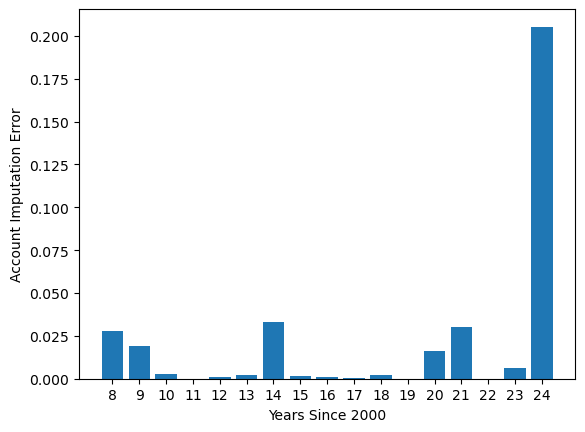

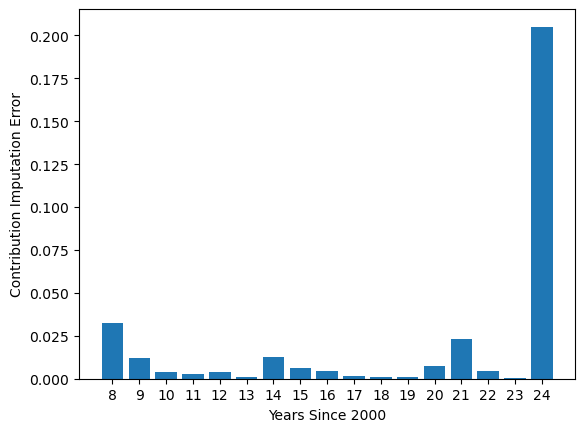

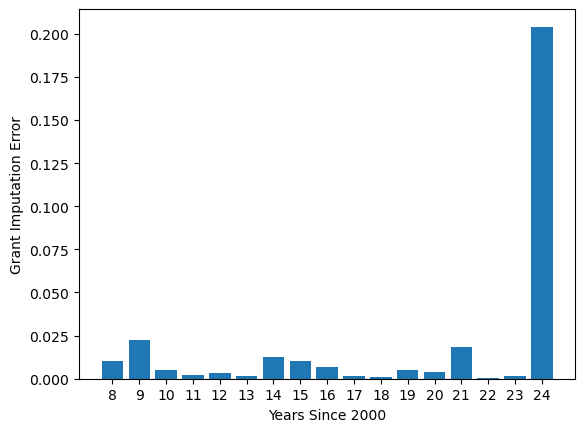

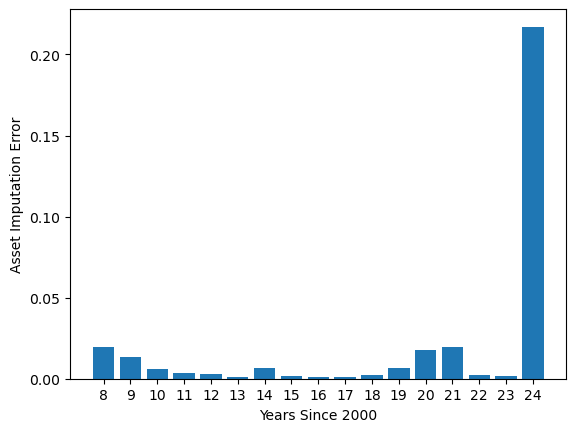

In [6]:
account_error_by_year = RE_account_by_year[1:]
contribution_error_by_year = RE_contributions_by_year[1:]
grant_error_by_year = RE_grants_by_year[1:]
asset_error_by_year = RE_assets_by_year[1:]

Year = range(7, 24)

plt.bar(Year, account_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Account Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, contribution_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Contribution Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, grant_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Grant Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, asset_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Asset Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()